In [1]:
import os
import pandas as pd
import snowflake.connector
import matplotlib.pyplot as plt


# Recuperar variables de entorno
SNOWFLAKE_ACCOUNT = os.getenv("SNOWFLAKE_ACCOUNT")
SNOWFLAKE_USER = os.getenv("SNOWFLAKE_USER")
SNOWFLAKE_PASSWORD = os.getenv("SNOWFLAKE_PASSWORD")
SNOWFLAKE_WAREHOUSE = os.getenv("SNOWFLAKE_WAREHOUSE")
SNOWFLAKE_DATABASE = os.getenv("SNOWFLAKE_DATABASE")
SNOWFLAKE_SCHEMA = os.getenv("SNOWFLAKE_SCHEMA")

# Conectar a Snowflake
conn = snowflake.connector.connect(
    user=SNOWFLAKE_USER,
    password=SNOWFLAKE_PASSWORD,
    account=SNOWFLAKE_ACCOUNT,
    warehouse=SNOWFLAKE_WAREHOUSE,
    database=SNOWFLAKE_DATABASE,
    schema=SNOWFLAKE_SCHEMA
)

print("Conexión a Snowflake establecida con éxito.")


Conexión a Snowflake establecida con éxito.


In [2]:
# Función para cargar una tabla desde Snowflake
def load_table(table_name):
    query = f'SELECT * FROM "{SNOWFLAKE_DATABASE}"."{SNOWFLAKE_SCHEMA}"."{table_name}"'
    return pd.read_sql(query, conn)

# Cargar las tablas en DataFrames
departments_df = load_table("DEPARTMENTS")
aisles_df = load_table("AISLES")
products_df = load_table("PRODUCTS")
instacart_orders_df = load_table("INSTACART_ORDERS")
order_products_df = load_table("ORDER_PRODUCTS")




/tmp/ipykernel_23703/2491795505.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


In [3]:
# Definir un diccionario con las tablas cargadas
tables = {
    "Departments": departments_df,
    "Aisles": aisles_df,
    "Products": products_df,
    "Instacart Orders": instacart_orders_df,
    "Order Products": order_products_df
}

# Imprimir la cantidad de filas y columnas de cada tabla
for table_name, df in tables.items():
    print(f" Dimensión de la tabla '{table_name}':")
    print(f"    Filas: {df.shape[0]}")
    print(f"    Columnas: {df.shape[1]}")
    print("-" * 40)



 Dimensión de la tabla 'Departments':
    Filas: 21
    Columnas: 2
----------------------------------------
 Dimensión de la tabla 'Aisles':
    Filas: 134
    Columnas: 2
----------------------------------------
 Dimensión de la tabla 'Products':
    Filas: 49694
    Columnas: 4
----------------------------------------
 Dimensión de la tabla 'Instacart Orders':
    Filas: 478967
    Columnas: 7
----------------------------------------
 Dimensión de la tabla 'Order Products':
    Filas: 4545007
    Columnas: 4
----------------------------------------


In [5]:
# Mostrar estadísticas descriptivas para cada tabla
for table_name, df in tables.items():
    print(f"Estadísticas descriptivas de la tabla '{table_name}':")
    
    # Estadísticas generales de las columnas numéricas
    stats = df.describe(include='all')
    print(stats)
    # Conteo de valores únicos por columna
    unique_counts = df.nunique()
    print("\nConteo de valores únicos por columna:")
    print(unique_counts)
    
    print("-" * 60)  # Separador entre tablas

Estadísticas descriptivas de la tabla 'Departments':
        department_id department
count       21.000000         21
unique            NaN         21
top               NaN     frozen
freq              NaN          1
mean        11.000000        NaN
std          6.204837        NaN
min          1.000000        NaN
25%          6.000000        NaN
50%         11.000000        NaN
75%         16.000000        NaN
max         21.000000        NaN

Conteo de valores únicos por columna:
department_id    21
department       21
dtype: int64
------------------------------------------------------------
Estadísticas descriptivas de la tabla 'Aisles':
          aisle_id                       aisle
count   134.000000                         134
unique         NaN                         134
top            NaN  specialty wines champagnes
freq           NaN                           1
mean     67.500000                         NaN
std      38.826537                         NaN
min       1.000000   

Histogramas con KDE de la tabla 'Departments':


/tmp/ipykernel_23703/2123957757.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 1, 1, 0.5])  # Ajustar layout


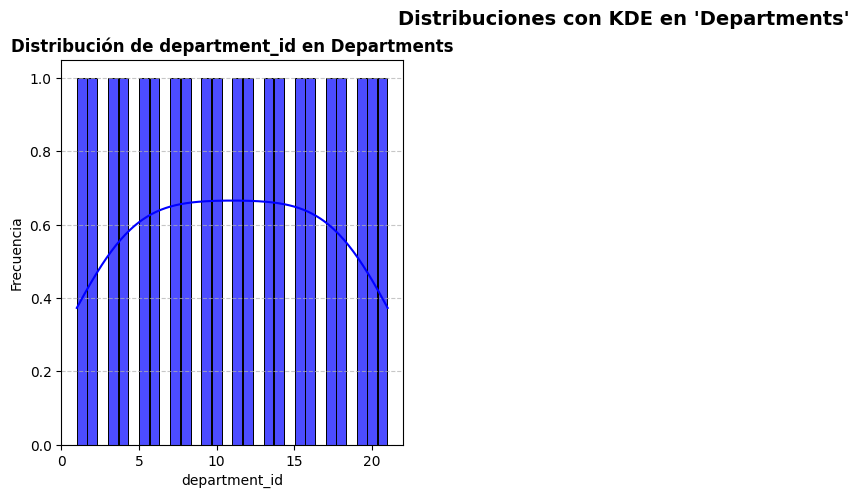

Histogramas con KDE de la tabla 'Aisles':


/tmp/ipykernel_23703/2123957757.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 1, 1, 0.5])  # Ajustar layout


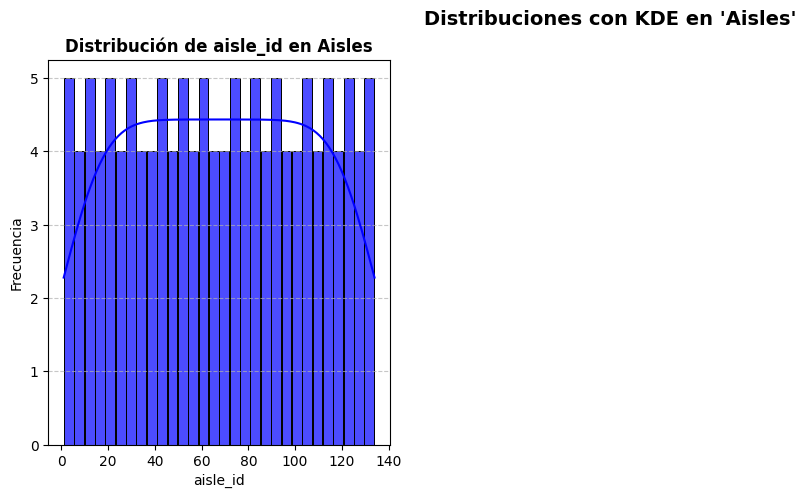

Histogramas con KDE de la tabla 'Products':


/tmp/ipykernel_23703/2123957757.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 1, 1, 0.5])  # Ajustar layout


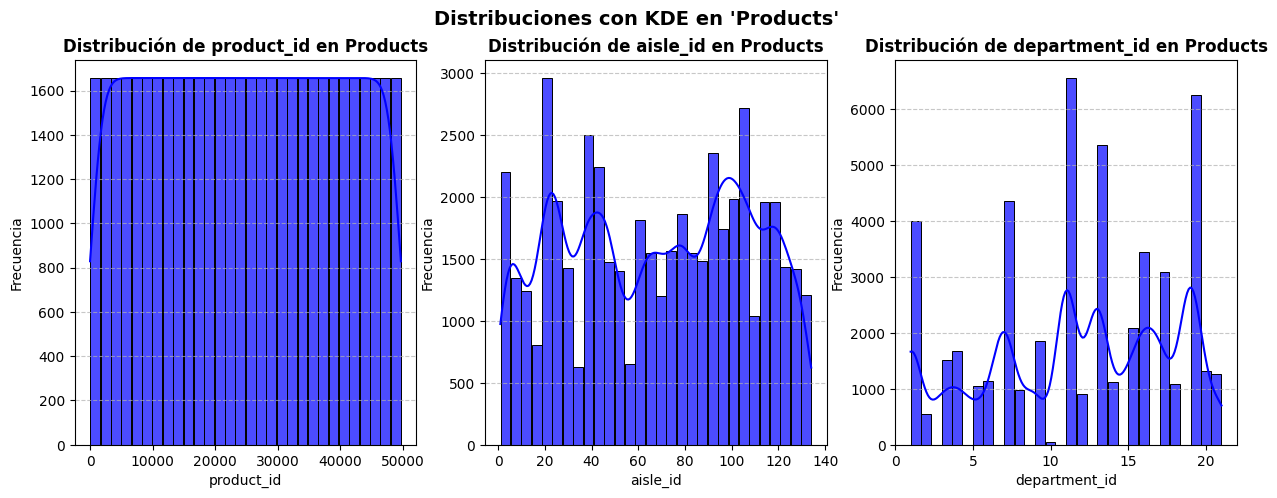

Histogramas con KDE de la tabla 'Instacart Orders':


/tmp/ipykernel_23703/2123957757.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 1, 1, 0.5])  # Ajustar layout


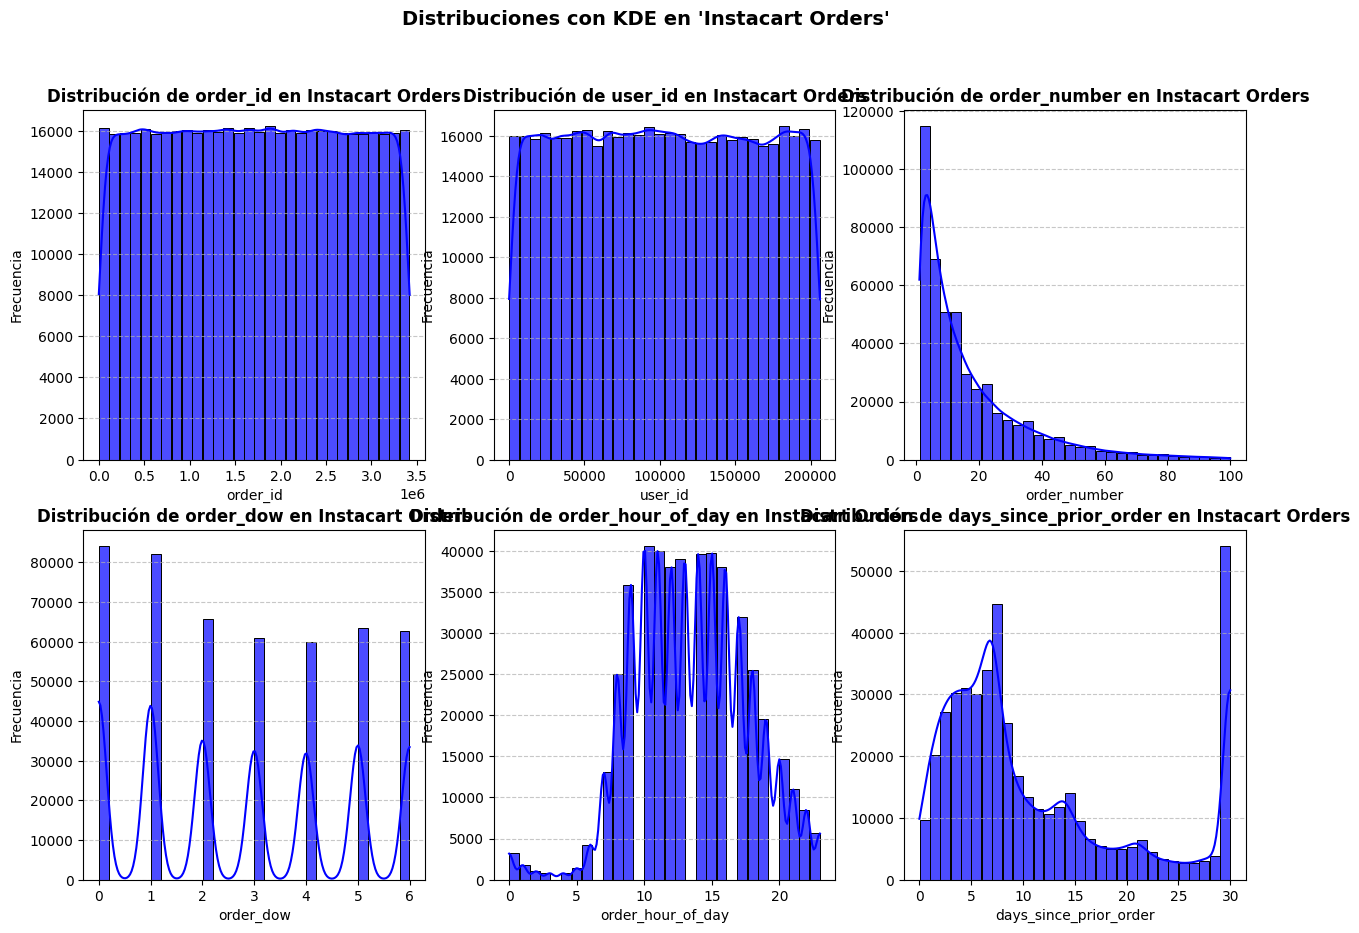

Histogramas con KDE de la tabla 'Order Products':


/tmp/ipykernel_23703/2123957757.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 1, 1, 0.5])  # Ajustar layout


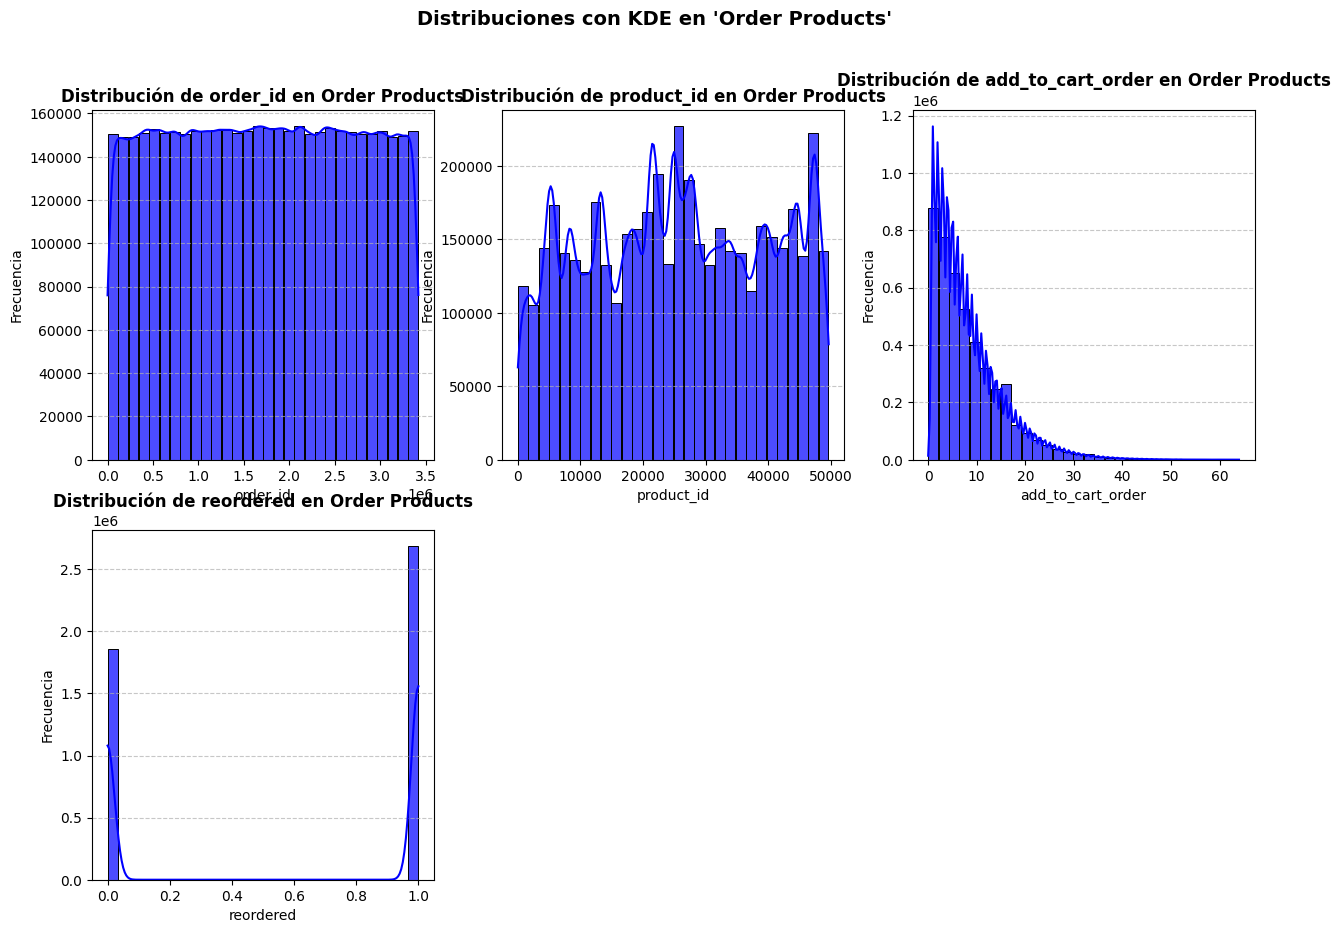

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generar histogramas ajustados con líneas de densidad para cada tabla
for table_name, df in tables.items():
    numeric_cols = df.select_dtypes(include=['number']).columns  # Seleccionar solo columnas numéricas
    
    if len(numeric_cols) > 0:
        print(f"Histogramas con KDE de la tabla '{table_name}':")
        
        # Definir número de filas y columnas para los subgráficos
        num_cols = len(numeric_cols)
        rows = (num_cols // 3) + (num_cols % 3 > 0)  # Organiza en filas de 3 columnas
        
        fig, axes = plt.subplots(rows, 3, figsize=(15, 5 * rows))
        axes = axes.flatten()  # Asegurar que sea iterable para cualquier cantidad de columnas
        
        for i, col in enumerate(numeric_cols):
            ax = axes[i]
            sns.histplot(df[col], kde=True, bins=30, color='blue', ax=ax, edgecolor='black', alpha=0.7, shrink=0.95)
            ax.set_title(f"Distribución de {col} en {table_name}", fontsize=12, fontweight='bold')
            ax.set_xlabel(col, fontsize=10)
            ax.set_ylabel("Frecuencia", fontsize=10)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        # Eliminar gráficos vacíos si hay menos de 3 columnas
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.suptitle(f"Distribuciones con KDE en '{table_name}'", fontsize=14, fontweight='bold')
        plt.tight_layout(rect=[0, 1, 1, 0.5])  # Ajustar layout
        plt.show()
    
    else:
        print(f"No hay columnas numéricas en la tabla '{table_name}', se omite el histograma.")


In [7]:
# Análisis de problemas de calidad: NULL, NaN y registros duplicados
for table_name, df in tables.items():
    print(f"Análisis de calidad de datos en la tabla '{table_name}':")
    
    # Contar valores NULL (originalmente de la base de datos)
    null_values = df.isna().sum()
    
    # Contar valores NaN (introducidos en pandas)
    nan_values = df.isnull().sum() - null_values
    
    # Calcular el total de valores ausentes
    total_missing = null_values + nan_values
    
    # Contar registros duplicados
    duplicate_count = df.duplicated().sum()
    
    # Crear un resumen
    total_null = null_values.sum()
    total_nan = nan_values.sum()
    
    print(f"Tabla: {table_name}")
    print(f"Registros duplicados: {duplicate_count}")
    print(f"Registros NULL: {total_null}")
    print(f"Registros NaN: {total_nan}")
    print("-" * 60)

    # Detalles por columna
    quality_df = pd.DataFrame({
        "Valores NULL (DB)": null_values,
        "Valores NaN (pandas)": nan_values,
        "Total de valores ausentes": total_missing,
        "Porcentaje de valores ausentes (%)": (total_missing / len(df)) * 100
    }).sort_values(by="Total de valores ausentes", ascending=False)
    
    if total_missing.any() or duplicate_count > 0:
        print(quality_df)
    else:
        print("No hay valores ausentes (NULL o NaN) ni registros duplicados en esta tabla.")
    
    print("-" * 60)  # Separador entre tablas


Análisis de calidad de datos en la tabla 'Departments':
Tabla: Departments
Registros duplicados: 0
Registros NULL: 0
Registros NaN: 0
------------------------------------------------------------
No hay valores ausentes (NULL o NaN) ni registros duplicados en esta tabla.
------------------------------------------------------------
Análisis de calidad de datos en la tabla 'Aisles':
Tabla: Aisles
Registros duplicados: 0
Registros NULL: 0
Registros NaN: 0
------------------------------------------------------------
No hay valores ausentes (NULL o NaN) ni registros duplicados en esta tabla.
------------------------------------------------------------
Análisis de calidad de datos en la tabla 'Products':
Tabla: Products
Registros duplicados: 0
Registros NULL: 0
Registros NaN: 0
------------------------------------------------------------
No hay valores ausentes (NULL o NaN) ni registros duplicados en esta tabla.
------------------------------------------------------------
Análisis de calidad 

In [65]:
# Análisis de inconsistencias en tipos de datos para cada tabla
for table_name, df in tables.items():
    print(f"Análisis de inconsistencias en tipos de datos en la tabla '{table_name}':")
    
    # Inspeccionar cada columna
    inconsistencies = {}
    for col in df.columns:
        col_dtype = df[col].dtype  # Tipo de datos detectado por pandas
        unique_types = df[col].apply(type).value_counts()  # Tipos presentes en la columna
        
        # Verificar si hay más de un tipo de dato en la columna
        if len(unique_types) > 1:
            inconsistencies[col] = {
                "Tipo de dato principal (pandas)": col_dtype,
                "Tipos encontrados": unique_types.to_dict()
            }
    
    # Reportar resultados
    if inconsistencies:
        for col, details in inconsistencies.items():
            print(f"Columna '{col}' tiene inconsistencias:")
            print(f"   Tipo de dato principal (pandas): {details['Tipo de dato principal (pandas)']}")
            print(f"   Tipos encontrados: {details['Tipos encontrados']}")
    else:
        print("No se encontraron inconsistencias en los tipos de datos.")
    
    print("-" * 60)  # Separador entre tablas


Análisis de inconsistencias en tipos de datos en la tabla 'Departments':
No se encontraron inconsistencias en los tipos de datos.
------------------------------------------------------------
Análisis de inconsistencias en tipos de datos en la tabla 'Aisles':
No se encontraron inconsistencias en los tipos de datos.
------------------------------------------------------------
Análisis de inconsistencias en tipos de datos en la tabla 'Products':
No se encontraron inconsistencias en los tipos de datos.
------------------------------------------------------------
Análisis de inconsistencias en tipos de datos en la tabla 'Instacart Orders':
No se encontraron inconsistencias en los tipos de datos.
------------------------------------------------------------
Análisis de inconsistencias en tipos de datos en la tabla 'Order Products':
No se encontraron inconsistencias en los tipos de datos.
------------------------------------------------------------


In [66]:
# Identificar valores atípicos en cada tabla
for table_name, df in tables.items():
    print(f"Análisis de valores atípicos en la tabla '{table_name}':")
    
    numeric_cols = df.select_dtypes(include=['number']).columns  # Seleccionar columnas numéricas
    
    if len(numeric_cols) > 0:
        for col in numeric_cols:
            # Calcular el rango intercuartílico (IQR)
            Q1 = df[col].quantile(0.25)  # Primer cuartil
            Q3 = df[col].quantile(0.75)  # Tercer cuartil
            IQR = Q3 - Q1  # Rango intercuartílico

            # Limites inferior y superior
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Identificar outliers
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
            outlier_count = len(outliers)
            
            # Mostrar resultados
            print(f"  Columna '{col}':")
            print(f"    Rango intercuartílico (IQR): {IQR}")
            print(f"    Límite inferior: {lower_bound}, Límite superior: {upper_bound}")
            print(f"    Valores atípicos detectados: {outlier_count}")
    else:
        print("No hay columnas numéricas en esta tabla para analizar valores atípicos.")
    
    print("-" * 60)  # Separador entre tablas


Análisis de valores atípicos en la tabla 'Departments':
  Columna 'department_id':
    Rango intercuartílico (IQR): 10.0
    Límite inferior: -9.0, Límite superior: 31.0
    Valores atípicos detectados: 0
------------------------------------------------------------
Análisis de valores atípicos en la tabla 'Aisles':
  Columna 'aisle_id':
    Rango intercuartílico (IQR): 66.5
    Límite inferior: -65.5, Límite superior: 200.5
    Valores atípicos detectados: 0
------------------------------------------------------------
Análisis de valores atípicos en la tabla 'Products':
  Columna 'product_id':
    Rango intercuartílico (IQR): 24846.5
    Límite inferior: -24845.5, Límite superior: 74540.5
    Valores atípicos detectados: 0
  Columna 'aisle_id':
    Rango intercuartílico (IQR): 65.0
    Límite inferior: -62.5, Límite superior: 197.5
    Valores atípicos detectados: 0
  Columna 'department_id':
    Rango intercuartílico (IQR): 10.0
    Límite inferior: -8.0, Límite superior: 32.0
    Val

1. Hallazgos sobre la Calidad de los Datos

El análisis exploratorio reveló valores ausentes, registros duplicados y valores atípicos en las tablas analizadas. En Instacart Orders, se encontraron 28,819 valores NULL en days_since_prior_order, representando 6.02% del total, mientras que 15 registros duplicados requieren depuración. No se hallaron valores NaN en ninguna de las tablas.

Respecto a valores atípicos, en Instacart Orders se detectaron anomalías en order_number (30,182 casos) y order_hour_of_day (3,180 casos). En Order Products, add_to_cart_order mostró 190,971 registros fuera del rango esperado. Si bien algunos valores extremos pueden representar comportamientos legítimos, es necesario evaluar su impacto antes de tomar acciones correctivas.

No se encontraron inconsistencias en los tipos de datos entre las tablas, lo que sugiere una estructura uniforme en la base de datos.

2. Plan de Transformación y Curación de Datos

Para garantizar la calidad de los datos y optimizar su usabilidad, se implementará una estrategia de transformación y curación estructurada. Se revisarán los valores ausentes en days_since_prior_order, considerando si representan compras iniciales o si requieren imputación con valores como la mediana del conjunto de datos. Los registros duplicados identificados en Instacart Orders serán eliminados para evitar distorsiones en los análisis posteriores.

En cuanto a los valores atípicos, se evaluará su impacto en las métricas clave y, en caso de ser necesario, se aplicarán técnicas como truncamiento, normalización o categorización para evitar sesgos. También se revisará la coherencia en los tipos de datos y nombres de columnas para garantizar la consistencia en futuras consultas y análisis. Finalmente, se establecerán reglas de validación automática para prevenir la reincidencia de estos problemas en cargas de datos futuras.

3. Próximos Pasos

Una vez implementadas las estrategias de transformación y curación, se llevará a cabo un nuevo análisis exploratorio para verificar que los ajustes hayan mejorado la calidad de los datos. Posteriormente, se documentarán los cambios realizados, incluyendo detalles sobre la eliminación de duplicados, la imputación de valores ausentes y el tratamiento de valores atípicos, asegurando que cada modificación esté debidamente justificada.

Además, se diseñarán mecanismos de control de calidad que permitan detectar y corregir anomalías en el flujo de datos antes de su uso en análisis avanzados. La integración de reglas de validación y monitoreo facilitará la detección temprana de problemas y garantizará la confiabilidad del dataset a largo plazo. Este enfoque asegurará que los datos sean precisos, consistentes y óptimos para la toma de decisiones estratégicas.